# Animal Detection in Camera Trap Images

**Course:** Neural Networks  
**Project stage:** Project Topic Meeting  
**Task type:** Object Detection  

## Team Members
- Kamila Korczyńska
- Kamil Tasarz


## Project Overview

This project focuses on **animal detection in camera trap images**. The goal is to determine whether an animal is present in an image and, if so, localize it with one or more bounding boxes.

The project is planned as a reproducible semester assignment for a two-person team. The emphasis is on a clear problem definition, a realistic baseline, and meaningful analysis rather than on building a production-ready system.

## Problem Definition

We define the project as an **object detection** task.

Let the dataset be denoted by

$\mathcal{D} = \{(I_i, Y_i)\}_{i=1}^{N}$,

where:
- $I_i \in \mathbb{R}^{H \times W \times C}$ is a camera trap image,
- $Y_i = \{(b_{ij}, \ell_{ij})\}_{j=1}^{M_i}$ is the set of annotated objects in the image,
- $b_{ij} = (x_{ij}, y_{ij}, w_{ij}, h_{ij})$ denotes a bounding box, for example by its top-left corner and box width and height,
- $\ell_{ij}$ is the corresponding object label.

The number of objects $M_i$ may vary between images. In particular:
- $M_i = 0$ for **empty images** with no animals,
- $M_i = 1$ for images with a single visible animal,
- $M_i > 1$ for images containing multiple animals.

**Input:** one camera trap image  
**Output:** a set of predicted bounding boxes and labels  
**Goal:** learn a function

$f : \mathbb{R}^{H \times W \times C} \rightarrow \{(\hat{b}_k, \hat{\ell}_k)\}_{k=1}^{\hat{M}}$

that predicts the locations and labels of animal instances in previously unseen images.

In the core version of the project, the label can be treated as a generic **animal** category. An optional extension is to predict species labels for detected animals.

This task differs from image classification: classification assigns one label to the whole image, whereas detection predicts zero, one, or many localized object instances.

## Why This Problem Matters

Camera traps generate large amounts of ecological data, and manual review is slow and expensive. This is especially true when many frames are empty or when animals are small, partially visible, or difficult to locate.

A reliable detection model could support biodiversity monitoring, wildlife surveys, and annotation workflows by filtering empty frames and highlighting animal locations for further analysis.

## Dataset: ENA24

The project will use **ENA24**, a camera trap dataset intended for wildlife analysis in natural environments. For this project, the most important property of the dataset is that it provides **bounding box annotations** for animal instances, which makes it suitable for object detection.

At a high level, ENA24 contains:
- camera trap images collected in real outdoor conditions,
- annotations that include bounding boxes for animals,
- images that may contain no animals, one animal, or multiple animals,
- visual variability typical of wildlife monitoring data.

Because the images come from real camera traps, they may include difficult conditions such as night-time imagery, motion blur, partial visibility, occlusion, and cluttered backgrounds. These properties make the dataset both challenging and realistic for the planned project.

### Why ENA24 is suitable for our project

ENA24 is suitable because its annotations include **bounding boxes**, so it supports the core task directly: detecting animals and localizing them in the image. This is essential for an object detection project and more appropriate than a dataset designed only for image-level classification.

The dataset is also relevant from an application perspective. Since it contains wildlife data collected in natural environments, it reflects realistic challenges in ecology and biodiversity monitoring. This makes it a strong choice for a semester project that aims to combine practical relevance with a clear machine learning objective.

At this stage, we avoid claiming exact dataset statistics unless they are verified locally. The final implementation details will depend on the confirmed annotation format and data organization of ENA24.

In [33]:
from pathlib import Path

# Default path for the lightweight ENA24 development sample.
DATASET_DIR = Path("data/ena24_sample")
ANNOTATIONS_PATH = DATASET_DIR / "annotations.json"
IMAGE_DIR = DATASET_DIR / "images"

print("Dataset directory:", DATASET_DIR.resolve())
print("Dataset directory exists:", DATASET_DIR.exists())
print("Image directory exists:", IMAGE_DIR.exists())
print("Annotation file exists:", ANNOTATIONS_PATH.exists())

Dataset directory: C:\Users\user\OneDrive\Desktop\NN-project\data\ena24_sample
Dataset directory exists: True
Image directory exists: True
Annotation file exists: True


## Example Data

This section is intended to show what **object detection** means in practice. Once the local ENA24 sample files are available, we will load a few sample images and overlay their bounding box annotations.

When viewing the examples, the main points to notice are:
- some images may be **empty**,
- some images may contain **one animal**,
- some images may contain **multiple animals**,
- bounding boxes indicate **where** the model is expected to detect animals.

The following cells use a clean placeholder workflow and may require small adjustments once the exact ENA24 annotation schema is confirmed.

In [34]:
import json
from collections import defaultdict

# TODO: adapt this cell if the final ENA24 annotation schema differs.
# Assumption: annotations follow a COCO-like JSON structure.
annotation_data = None
image_records = []
annotation_records = []
category_id_to_name = {}
image_id_to_annotations = defaultdict(list)

if ANNOTATIONS_PATH.exists():
    with ANNOTATIONS_PATH.open("r", encoding="utf-8") as f:
        annotation_data = json.load(f)

    print("Loaded annotation file:", ANNOTATIONS_PATH)
    if isinstance(annotation_data, dict):
        print("Top-level keys:", sorted(annotation_data.keys()))

        image_records = annotation_data.get("images", [])
        annotation_records = annotation_data.get("annotations", [])

        for category in annotation_data.get("categories", []):
            if isinstance(category, dict) and "id" in category:
                category_id_to_name[category["id"]] = category.get("name", str(category["id"]))

        for annotation in annotation_records:
            if isinstance(annotation, dict) and "image_id" in annotation:
                image_id_to_annotations[annotation["image_id"]].append(annotation)

        print(f"Images found in annotations: {len(image_records)}")
        print(f"Annotations found: {len(annotation_records)}")
    else:
        print("Annotation file was loaded, but its structure is not a dictionary.")
else:
    print("Annotation file not found.")
    print("TODO: update ANNOTATIONS_PATH after the dataset is selected.")

Loaded annotation file: data\ena24_sample\annotations.json
Top-level keys: ['annotations', 'categories', 'images', 'info']
Images found in annotations: 30
Annotations found: 33


### Preview Images with Bounding Boxes

The next cell attempts to display a few representative images together with their annotations. The purpose is not detailed analysis yet, but a quick visual explanation of the task: the model must identify **where** animals are located in the image, not only whether an animal is present.

If the local ENA24 paths or JSON fields differ from the assumptions below, the marked `TODO` lines should be adjusted.

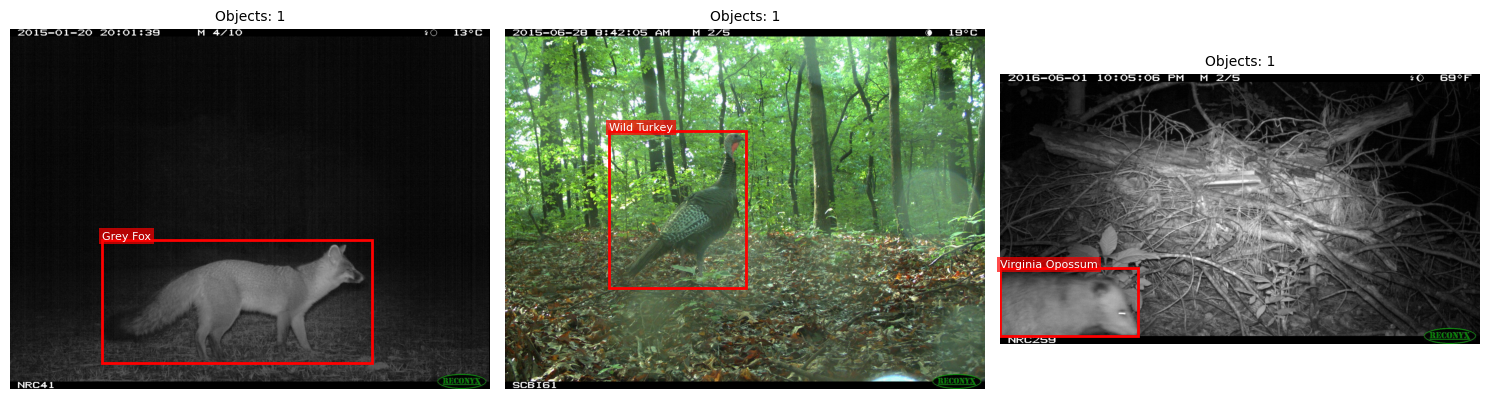

In [35]:
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# TODO: adjust image path resolution if ENA24 uses a different folder layout.
# TODO: adjust bounding box access if the final annotation format is not COCO-like.

def resolve_image_path(image_record):
    file_name = image_record.get("file_name") or image_record.get("path") or image_record.get("image_path")
    if not file_name:
        return None

    candidates = [
        IMAGE_DIR / file_name,
        DATASET_DIR / file_name,
        Path(file_name),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


if not image_records:
    print("No image records are available yet.")
    print("TODO: confirm the ENA24 annotation structure and local paths.")
else:
    random.seed(2137)

    images_with_boxes = [img for img in image_records if image_id_to_annotations.get(img.get("id"))]
    empty_images = [img for img in image_records if not image_id_to_annotations.get(img.get("id"))]

    selected_images = []
    if images_with_boxes:
        selected_images.extend(random.sample(images_with_boxes, k=min(3, len(images_with_boxes))))
    if empty_images:
        selected_images.extend(random.sample(empty_images, k=min(1, len(empty_images))))

    selected_images = selected_images[:4]

    if not selected_images:
        print("No suitable sample images were selected.")
    else:
        fig, axes = plt.subplots(1, len(selected_images), figsize=(5 * len(selected_images), 5))
        if len(selected_images) == 1:
            axes = [axes]

        for ax, image_record in zip(axes, selected_images):
            image_path = resolve_image_path(image_record)
            if image_path is None:
                ax.text(0.5, 0.5, "Image file not found", ha="center", va="center")
                ax.axis("off")
                continue

            image = Image.open(image_path)
            ax.imshow(image)
            ax.axis("off")

            annotations = image_id_to_annotations.get(image_record.get("id"), [])
            ax.set_title(f"Objects: {len(annotations)}", fontsize=10)

            for annotation in annotations:
                bbox = annotation.get("bbox")
                if not bbox or len(bbox) != 4:
                    continue

                x, y, w, h = bbox
                rect = Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)

                category_id = annotation.get("category_id")
                label = category_id_to_name.get(category_id, str(category_id)) if category_id is not None else "animal"
                ax.text(
                    x,
                    max(0, y - 4),
                    label,
                    color="white",
                    fontsize=8,
                    bbox={"facecolor": "red", "alpha": 0.7, "pad": 2, "edgecolor": "none"},
                )

        plt.tight_layout()
        plt.show()

## Main Challenges

Camera trap object detection is challenging because:
- many images may be **empty**, so the model must avoid false positives,
- some images may contain **multiple animals**, requiring several correct detections,
- animals may be small, distant, partially visible, or occluded,
- lighting conditions vary strongly, including daylight and night-time infrared imagery,
- motion blur and background clutter can make localization difficult,
- annotation quality and dataset format may require additional inspection.

These factors make the problem realistic and suitable for meaningful experiments in a semester project.

## Proposed Approach

The project will begin with a standard **object detection baseline** based on a pre-trained detector. A realistic starting point for a two-person team is to adapt an existing model such as **YOLO** or **Faster R-CNN** to the selected camera trap dataset.

At a high level, the plan is to:
- choose one pre-trained detector as the **baseline**,
- adapt it for animal detection in camera trap images,
- use the baseline as the main reference point for later experiments,
- test whether simple changes can improve performance over the baseline.

A possible extension is a **two-stage pipeline**:
- first, detect animals in the image,
- then classify each detected region into species categories.

This extension is optional. The core project goal remains animal detection, which keeps the scope realistic for a two-person team.

## Evaluation Metrics

Because this is an **object detection** project, evaluation must measure both **whether the model finds the animal** and **how accurately it localizes it**.

### IoU (Intersection over Union)

IoU measures how well a predicted bounding box overlaps with the ground-truth box. A higher IoU means that the predicted location is closer to the true object location.

### Precision and Recall in Detection

In the detection setting:
- **precision** reflects how many predicted detections are actually correct,
- **recall** reflects how many real animal instances were successfully detected.

This matters because a model may produce too many false alarms or miss many animals.

### mAP (mean Average Precision)

mAP is a standard summary metric for object detection. Intuitively, it combines localization quality and detection quality into one overall measure, making it more informative than a single image-level score.

### Why Accuracy Is Not Enough

Simple accuracy works for classification tasks where each image has one label. In object detection, an image may contain zero, one, or multiple objects, and each prediction must include both a label and a location. For this reason, detection-specific metrics such as IoU, precision, recall, and mAP are more appropriate.

## Feasibility and Project Scope

The project is feasible for a two-person team if the scope remains focused. The core task is a well-defined **animal detection** problem with a reproducible baseline and a limited number of controlled experiments.

To keep the workload realistic within one semester, we may:
- use one carefully selected dataset,
- focus first on a single generic **animal** class,
- treat species classification as an optional extension.

This keeps the project aligned with course expectations: a working implementation, reproducible experiments, comparison of approaches, and clear analysis.

## Next Steps

The next steps after the project topic meeting are:
1. finalize the detection dataset,
2. inspect the annotation format and verify bounding box quality,
3. prepare a lightweight data loading pipeline,
4. define the baseline detector,
5. plan the first controlled experiments.

Once the dataset is finalized, this notebook can be extended with concrete examples, annotation visualizations, and a more detailed experimental plan.